In [2]:
import optuna
import itertools

/home/guilherme/Repositories/data-driven-studies/droplet/.env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
simulations = ['collision', 'spreading']
kernels = ['poly', 'rbf', 'sigmoid']

In [4]:
for simulation, kernel in itertools.product(simulations, kernels):
    study = optuna.load_study(
        study_name=f'{simulation}_{kernel}',
        storage=f'sqlite:///.optunadb/{simulation}_{kernel}.db'
    )
    print(simulation, kernel)
    print(study.best_params)

collision poly
{'degree': 2, 'gamma': 0.08844925325508515, 'coef0': 79.18049805687012}
collision rbf
{'gamma': 0.12778127370318793}
collision sigmoid
{'gamma': 4.533533593261225e-06, 'coef0': 63.085957439648}
spreading poly
{'degree': 4, 'gamma': 4.782262457743407e-05, 'coef0': 78.54213457279295}
spreading rbf
{'gamma': 0.5017214723000264}
spreading sigmoid
{'gamma': 0.10276416246675994, 'coef0': 1.955883827243806}


In [5]:
study_col_poly = optuna.load_study(
    study_name='collision_poly',
    storage='sqlite:///.optunadb/collision_poly.db'
)

In [8]:
study_df = study_col_poly.trials_dataframe()

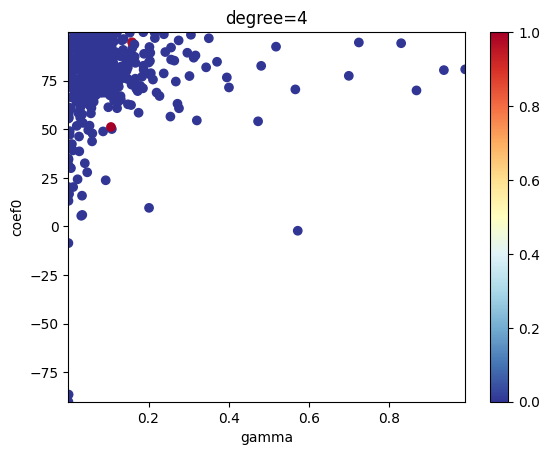

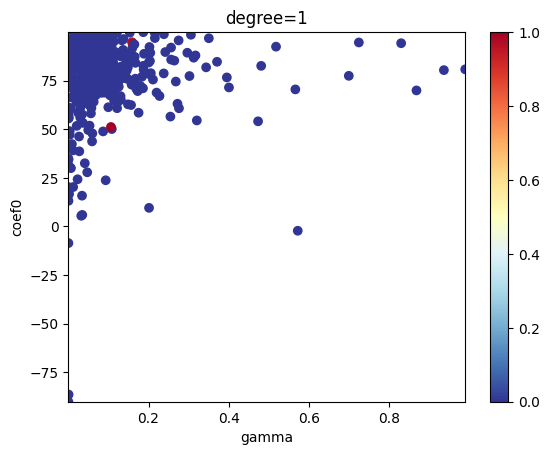

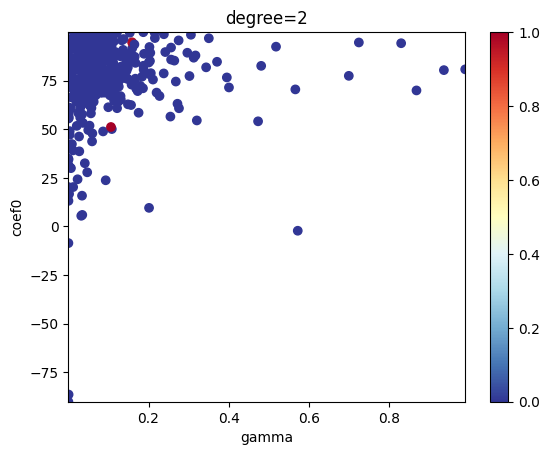

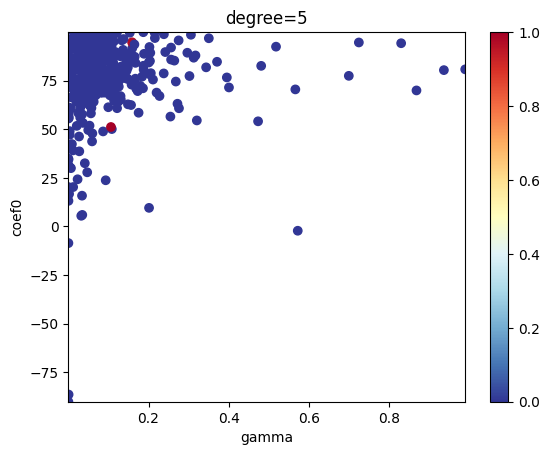

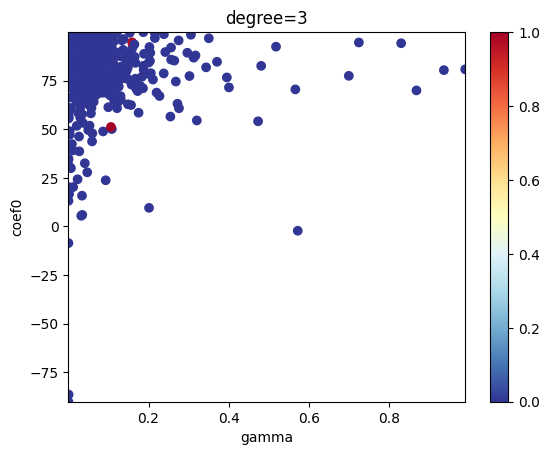

In [28]:
import numpy as np
import matplotlib.pyplot as plt

df = study_df[["params_coef0", "params_degree", "params_gamma", "value"]]
df = df.replace(np.inf, np.nan)
df = df.dropna()

degree_unique = df["params_degree"].unique()

for degree in degree_unique:
    fig, ax = plt.subplots()
    ax.set_title(f"degree={degree}")
    ax.set_xlabel("gamma")
    ax.set_ylabel("coef0")
    x = np.linspace(df["params_gamma"].min(), df["params_gamma"].max(), 100)
    y = np.linspace(df["params_coef0"].min(), df["params_coef0"].max(), 100)
    # let value be the color
    ax.scatter(df["params_gamma"], df["params_coef0"], c=df["value"], cmap='RdYlBu_r')
    ax.contour(x, y, np.ones((100, 100)) * df["value"].min(), levels=[df["value"].min() + 0.1], colors='red')
    # color bar
    cbar = plt.colorbar(ax.scatter([], [], c=[], cmap='RdYlBu_r'))
    plt.show()